In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset, Dataset
import sys 
sys.path.append("../")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = 10

# Load the CIFAR-10 dataset
train_ds = torchvision.datasets.CIFAR10(root='./data', train=True, download=True)
test_ds = torchvision.datasets.CIFAR10(root='./data', train=False, download=True)

print(f"Training samples: {len(train_ds)}, Test samples: {len(test_ds)}")

mean = torch.tensor([0.4914, 0.4822, 0.4465])
std = torch.tensor([0.2023, 0.1994, 0.2010])

Training samples: 50000, Test samples: 10000


In [2]:
class RandomRangAugment(transforms.RandAugment):
    def __init__(self, num_ops=2):
        super().__init__(num_ops=num_ops)

    def __call__(self, img):
        # just randaugment with random magnitude
        self.magnitude = torch.randint(0, self.num_magnitude_bins, (1,)).item()
        img = super().__call__(img)
        return img

In [3]:
norm_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean, std)
    ])

weak_transform = transforms.Compose([
        transforms.RandomHorizontalFlip(),
        transforms.RandomCrop(32, padding=4),
        transforms.ToTensor(),
        transforms.Normalize(mean, std)
    ])

medium_transform = transforms.Compose([
        transforms.RandomHorizontalFlip(),
        transforms.RandomCrop(32, padding=4),
        RandomRangAugment(num_ops=1),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
        transforms.RandomErasing(),
    ])

strong_transform=transforms.Compose([
        RandomRangAugment(num_ops=3),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
        transforms.RandomErasing()
    ])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.9802322e-08..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.9802322e-08..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.9802322e-08..0.99607843].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.9802322e-08..1.0].


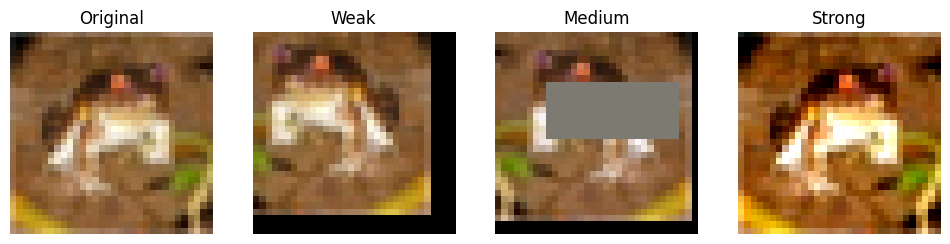

In [4]:
# Test transformation on a sample image
import matplotlib.pyplot as plt
def imshow(img, title=None):
    img = img * std[:, None, None] + mean[:, None, None]  # unnormalize
    img = img.permute(1, 2, 0).numpy()  # CxHxW to HxWxC
    plt.imshow(img)
    if title:
        plt.title(title)
    plt.axis('off')
sample_img, sample_label = train_ds[0]
plt.figure(figsize=(12, 4))
plt.subplot(1, 4, 1)
imshow(norm_transform(sample_img), title="Original")
plt.subplot(1, 4, 2)
imshow(weak_transform(sample_img), title="Weak")
plt.subplot(1, 4, 3)
imshow(medium_transform(sample_img), title="Medium")
plt.subplot(1, 4, 4)
imshow(strong_transform(sample_img), title="Strong")
plt.show()

In [5]:
class UnlabeledDataset(Dataset):
    def __init__(self, dataset, weak_transform, medium_transform, strong_transform):
        self.dataset = dataset
        self.weak_transform = weak_transform
        self.medium_transform = medium_transform
        self.strong_transform = strong_transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        x, _ = self.dataset[idx]
        x_w = self.weak_transform(x)
        x_m = self.medium_transform(x)
        x_s = self.strong_transform(x)
        return x_w, x_m, x_s, idx

In [6]:
from datasets import TransformedDataset
from wideresnet2 import WideResNet 
from utils import evaluate_f1_and_accuracy
import os
import json
import time

num_runs = 3

test_ds = TransformedDataset(test_ds, norm_transform)

for run in range(num_runs):
    print(f"Run {run+1}/{num_runs}")

    # Init random seeds for reproducibility
    torch.manual_seed(run)
    num_labeled = 40
    perm_indices = torch.randperm(len(train_ds))
    labeled_indices = perm_indices[:num_labeled]
    unlabeled_indices = perm_indices[num_labeled:]

    # Create datasets and dataloaders
    labeled_ds = TransformedDataset(Subset(train_ds, labeled_indices), weak_transform)
    unlabeled_ds = UnlabeledDataset(Subset(train_ds, unlabeled_indices), weak_transform, medium_transform, strong_transform)

    # Create dataloaders
    batch_size = 64
    mu = 1
    labeled_loader = DataLoader(labeled_ds, batch_size=batch_size, shuffle=True)
    unlabeled_loader = DataLoader(unlabeled_ds, batch_size=batch_size*mu, shuffle=True)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

    # Create iterators for the dataloaders
    labeled_iter = iter(labeled_loader)
    unlabeled_iter = iter(unlabeled_loader)

    # Define the model
    model = WideResNet(depth=28, widen_factor=2, num_classes=num_classes).to(device)
    max_steps = 19_530  # Equivalent to 100 epochs on the full dataset with batch size 64
    optimizer = torch.optim.SGD(model.parameters(), lr=0.03, momentum=0.9, weight_decay=5e-4, nesterov=True)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max_steps)

    # Settings
    method_name = "SequenceMatch_mu_1"
    name_of_experiment = f"cifar10_{num_labeled}_labels_run_{run+1}"

    if os.path.exists(f"results/{name_of_experiment}/{method_name}.json"):
        print(f"Results for {name_of_experiment} already exist. Skipping saving to avoid overwriting.")
        break # this will skip the rest of the training loop and move to the next run

    # Metrics to track
    metrics = {
    "test_f1": [0.0],  # Start with 0% F1 before training
    "test_acc": [0.0],  # Start with 0% accuracy before training
    "budget": [0]
    }

    # Hyperparameters
    tau = 0.95
    T = 0.5
    budget_per_iteration = 1 + 3 * mu  # 1 batch of labeled + 3 batches of unlabeled (weak + medium + strong)
    test_budget_period = 1500  # Evaluate on test set every 1500 batches seen

    # Training loop
    current_budget = 0
    start_time = time.time()
    for step in range(max_steps):
        running_loss = 0.0
        running_loss_sup = 0.0
        running_loss_unsup = 0.0
        model.train()
        try:
            x_l, y_l = next(labeled_iter)
        except StopIteration:
            labeled_iter = iter(labeled_loader)
            x_l, y_l = next(labeled_iter)

        try:
            x_u_w, x_u_m, x_u_s, _ = next(unlabeled_iter)
        except StopIteration:
            unlabeled_iter = iter(unlabeled_loader)
            x_u_w, x_u_m, x_u_s, _ = next(unlabeled_iter)

        x_l, y_l = x_l.to(device), y_l.to(device)
        x_u_w, x_u_m, x_u_s = x_u_w.to(device), x_u_m.to(device), x_u_s.to(device)

        # supervised
        logits_l = model(x_l)
        loss_sup = F.cross_entropy(logits_l, y_l)

        # compute prediction on weakly augmented samples for pseudo-labeling and confidence-based masking
        logits_m = model(x_u_m)
        logits_s = model(x_u_s)
        with torch.no_grad():
            logits_w = model(x_u_w)
            probs_w = F.softmax(logits_w, dim=1)
            sharpened_probs_w = F.softmax(logits_w / T, dim=1)
            max_prob_w, pseudo_w = torch.max(probs_w, dim=1)
            mask_w = max_prob_w.ge(tau).float()

            probs_m = F.softmax(logits_m, dim=1)
            sharpened_probs_m = F.softmax(logits_m / T, dim=1)
            max_prob_m, pseudo_m = torch.max(probs_m, dim=1)
            mask_m = max_prob_m.ge(tau).float()

        loss_unsup_conf = (mask_w * F.cross_entropy(logits_s, pseudo_w, reduction='none')).mean()

        loss_consistency = loss_unsup_conf

        loss_w_m = (mask_w * F.kl_div(F.log_softmax(logits_m, dim=1), sharpened_probs_w, reduction='none').sum(dim=1)).mean()
        loss_m_s = (mask_m * F.kl_div(F.log_softmax(logits_s, dim=1), sharpened_probs_m, reduction='none').sum(dim=1)).mean()
        loss_w_s = (mask_w * F.kl_div(F.log_softmax(logits_s, dim=1), sharpened_probs_w, reduction='none').sum(dim=1)).mean()

        loss_unsup = loss_w_m + loss_m_s + loss_w_s  + loss_consistency 

        loss = loss_sup + loss_unsup
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler.step()

        running_loss += loss.item()
        running_loss_sup += loss_sup.item()
        running_loss_unsup += loss_unsup.item()

        current_budget += budget_per_iteration

        if current_budget % test_budget_period < budget_per_iteration:
            f1, acc = evaluate_f1_and_accuracy(model, test_loader, device)
            metrics["test_f1"].append(f1)
            metrics["test_acc"].append(acc)
            metrics["budget"].append(current_budget)
            elapsed_time = time.time() - start_time
            print(f"Step {step+1}/{max_steps}, Budget: {current_budget}, Loss: {running_loss:.4f}, Sup Loss: {running_loss_sup:.4f}, Unsup Loss: {running_loss_unsup:.4f}, Test F1: {f1:.4f}, Test Acc: {acc:.4f}, Elapsed Time: {elapsed_time:.2f}s", flush=True)

            os.makedirs("results", exist_ok=True)
            os.makedirs(f"results/{name_of_experiment}", exist_ok=True)
            with open(f"results/{name_of_experiment}/{method_name}.json", "w") as f:
                json.dump(metrics, f, indent=4)

            # Early stopping if divergence is detected (accuracy stagnating around 10% for 5 consecutive evaluations)
            early_stopping = (num_labeled == 40) and len(metrics["test_acc"]) > 5 and all(acc < 0.11 for acc in metrics["test_acc"][-5:])
            if early_stopping:
                print(f"Early stopping at step {step+1} due to potential divergence (accuracy stagnating around 10%).")
                
                # Fill the remaining metrics with the last known values until max_steps
                for remaining_step in range(step+1, max_steps):
                    current_budget += budget_per_iteration
                    if current_budget % test_budget_period < budget_per_iteration:
                        metrics["test_f1"].append(metrics["test_f1"][-1])  # Append last known F1
                        metrics["test_acc"].append(metrics["test_acc"][-1])  # Append last known accuracy
                        metrics["budget"].append(current_budget)
                # Save the final metrics after early stopping
                with open(f"results/{name_of_experiment}/{method_name}.json", "w") as f:
                    json.dump(metrics, f, indent=4)
                break 

        elif step+1 == max_steps: # Final evaluation at the end of training
            f1, acc = evaluate_f1_and_accuracy(model, test_loader, device)
            metrics["test_f1"].append(f1)
            metrics["test_acc"].append(acc)
            metrics["budget"].append(current_budget)
            elapsed_time = time.time() - start_time
            print(f"Step {step+1}/{max_steps}, Budget: {current_budget}, Loss: {running_loss:.4f}, Sup Loss: {running_loss_sup:.4f}, Unsup Loss: {running_loss_unsup:.4f}, Test F1: {f1:.4f}, Test Acc: {acc:.4f}, Elapsed Time: {elapsed_time:.2f}s", flush=True)

            os.makedirs("results", exist_ok=True)
            os.makedirs(f"results/{name_of_experiment}", exist_ok=True)
            with open(f"results/{name_of_experiment}/{method_name}.json", "w") as f:
                json.dump(metrics, f, indent=4) 

        else:
            print(f"Step {step+1}/{max_steps}, Budget: {current_budget}, Loss: {running_loss:.4f}, Sup Loss: {running_loss_sup:.4f}, Unsup Loss: {running_loss_unsup:.4f}", end="\r", flush=True)

Run 1/3
Step 375/19530, Budget: 1500, Loss: 0.9143, Sup Loss: 0.1066, Unsup Loss: 0.8077, Test F1: 0.1954, Test Acc: 0.2186, Elapsed Time: 34.97s
Step 750/19530, Budget: 3000, Loss: 0.0201, Sup Loss: 0.0112, Unsup Loss: 0.0089, Test F1: 0.0210, Test Acc: 0.1014, Elapsed Time: 65.93s
Step 1125/19530, Budget: 4500, Loss: 0.0041, Sup Loss: 0.0020, Unsup Loss: 0.0021, Test F1: 0.0182, Test Acc: 0.1000, Elapsed Time: 97.49s
Step 1500/19530, Budget: 6000, Loss: 0.0027, Sup Loss: 0.0013, Unsup Loss: 0.0014, Test F1: 0.0182, Test Acc: 0.1000, Elapsed Time: 128.88s
Step 1875/19530, Budget: 7500, Loss: 0.0029, Sup Loss: 0.0012, Unsup Loss: 0.0017, Test F1: 0.0182, Test Acc: 0.1000, Elapsed Time: 160.25s
Step 2250/19530, Budget: 9000, Loss: 0.0028, Sup Loss: 0.0017, Unsup Loss: 0.0010, Test F1: 0.0182, Test Acc: 0.1000, Elapsed Time: 191.52s
Early stopping at step 2250 due to potential divergence (accuracy stagnating around 10%).
Run 2/3
Step 375/19530, Budget: 1500, Loss: 0.8622, Sup Loss: 0.075